In [3]:
from utils import * 
import subprocess
import json
import itertools
import requests

%load_ext autoreload 
%autoreload 2

In [4]:
# No genes in this cluster have any InterProScan annotations. 

In [5]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.cluster_id == 6].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_6.faa')
# subprocess.run('muscle -align ../data/genes/cluster_6.faa -output ../data/genes/cluster_6.afa', shell=True, check=True)
for row in genes_df.itertuples():
    print(f'{row.Index}')

print('\nMinimum cluster_6 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_6 gene length:', genes_df.seq.apply(len).max())

orfm.bz_0.1_169
orfm.bz_1.1_143
orfm.bz_2.1_38
orfm.bz_3.1_56
orfm.bz_4.1_159
orfm.bz_5.1_136
orfm.bz_7.1_170
orfm.bz_8.1_202
orfm.bz_9.1_58
orfm.bz_10.1_27

Minimum cluster_6 gene length: 177
Maximum cluster_6 gene length: 253


In [6]:
with open('../data/genes/colabfold/plddts.json', 'r') as f:
    plddts = json.load(f)
genes_df['mean_plddt'] = genes_df.index.map({gene_id:np.mean(plddts_) for gene_id, plddts_ in plddts.items()})

def get_best_plddt_window(plddts, window_size:int=30):
    '''Compute the average pLDDT over windows of the sequence, and find the window with the highest local structure confidence.'''
    starts = np.arange(0, len(plddts) - window_size)
    stops = starts + window_size 
    mean_plddts = np.array([np.mean(plddts[start:stop]) for start, stop in zip(starts, stops)])
    idx = np.argmax(mean_plddts) # Get the index of the window with the best pLDDT. 
    return starts[idx], stops[idx], mean_plddts[idx]


for row in genes_df.itertuples():
    start, stop, best_plddt = get_best_plddt_window(plddts[row.Index])
    print(f'Best pLDDT for {row.genome_id} cluster_2 protein:', np.round(best_plddt, 3), f'({start}-{stop})', f'mean pLDDT: {row.mean_plddt:.2f}')

# Fairly weak structure predictions for all except the bz_3 protein. 

Best pLDDT for bz_0 cluster_2 protein: 44.712 (30-60) mean pLDDT: 33.61
Best pLDDT for bz_1 cluster_2 protein: 51.122 (36-66) mean pLDDT: 36.30
Best pLDDT for bz_2 cluster_2 protein: 48.6 (222-252) mean pLDDT: 36.96
Best pLDDT for bz_3 cluster_2 protein: 71.818 (35-65) mean pLDDT: 50.89
Best pLDDT for bz_4 cluster_2 protein: 47.094 (195-225) mean pLDDT: 36.77
Best pLDDT for bz_5 cluster_2 protein: 45.687 (40-70) mean pLDDT: 35.53
Best pLDDT for bz_7 cluster_2 protein: 58.273 (153-183) mean pLDDT: 45.78
Best pLDDT for bz_8 cluster_2 protein: 54.784 (65-95) mean pLDDT: 42.63
Best pLDDT for bz_9 cluster_2 protein: 33.8 (106-136) mean pLDDT: 29.39
Best pLDDT for bz_10 cluster_2 protein: 64.357 (35-65) mean pLDDT: 44.71


In [62]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
genes_df['num_tmhs'] = genes_df.index.map(tmhmm_file.get_num_tmhs())
    
# for row in genes_df.itertuples():
#     print(f'Number TMHs in {row.genome_id} cluster_6 protein:', row.num_tmhs)

tmhmm_df = tmhmm_file.to_df()
tmhmm_df = tmhmm_df[tmhmm_df.gene_id.isin(genes_df.index)].copy()
tmhmm_df = tmhmm_df[tmhmm_df.location == 'TMhelix'].copy()
genes_df['tmh_start'] = genes_df.index.map(tmhmm_df.set_index('gene_id').start)
genes_df['tmh_stop'] = genes_df.index.map(tmhmm_df.set_index('gene_id').end)

for row in genes_df.itertuples():
    seq = row.seq[row.tmh_start - 10:row.tmh_start]
    rk_count = seq.count('R') + seq.count('K')
    print(f'Number of positive residues before TMH in {row.genome_id}:', rk_count, f'\t{seq}')

Number of positive residues before TMH in bz_0: 3 	ERTGTKKDGV
Number of positive residues before TMH in bz_1: 3 	KVNKQKHEGL
Number of positive residues before TMH in bz_2: 1 	LQKPNNSIII
Number of positive residues before TMH in bz_3: 2 	VGKKDNSALM
Number of positive residues before TMH in bz_4: 2 	EKTGTKQDNI
Number of positive residues before TMH in bz_5: 3 	RVGKKDNSAL
Number of positive residues before TMH in bz_7: 1 	MNEKDNSGHV
Number of positive residues before TMH in bz_8: 3 	ERVGKKDNSA
Number of positive residues before TMH in bz_9: 1 	DINEKGNDGF
Number of positive residues before TMH in bz_10: 2 	RTGKGDNTVL


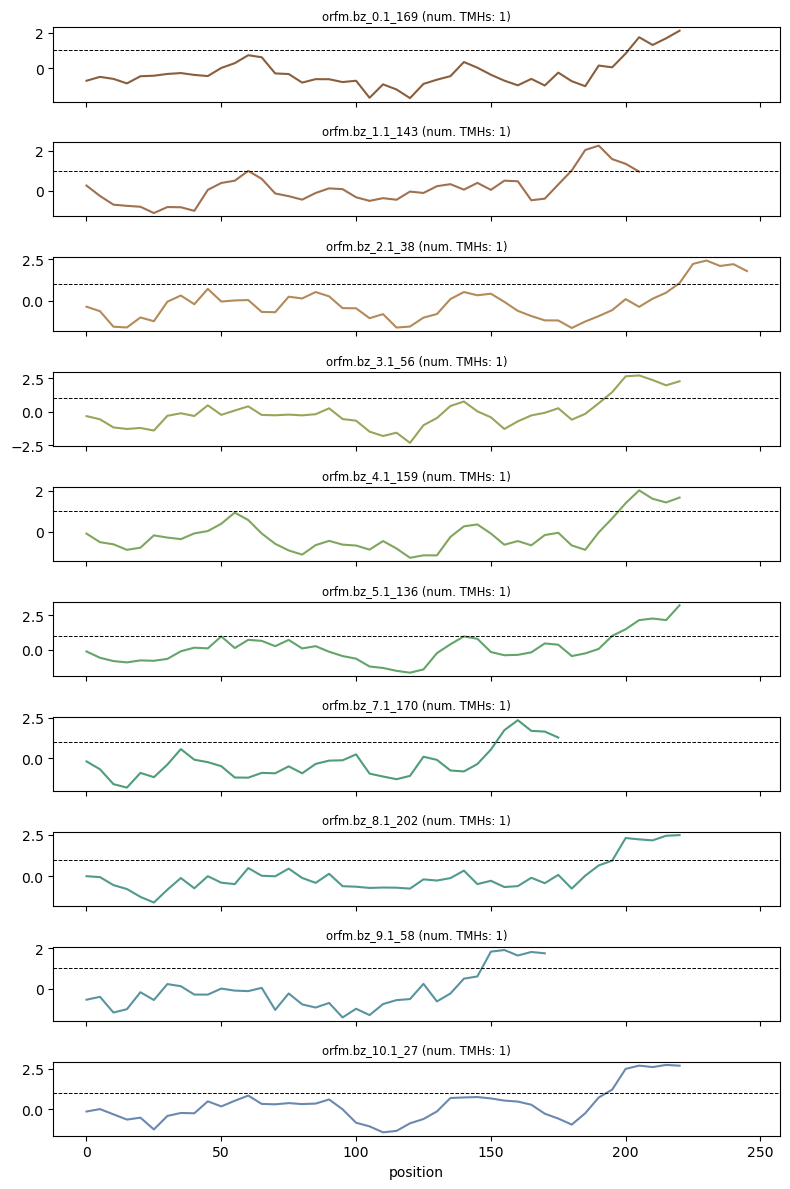

In [19]:
HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

window_size = 20
step_size = 5

get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

fig, axes = plt.subplots(figsize=(8, 12), nrows=len(genes_df), sharex=True)

for ax, row in zip(axes, genes_df.itertuples()):
    window_starts = list(range(0, len(row.seq), step_size))[:-1]
    windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]

    hydrophobicity = [get_hydrophobicity(seq) for seq in windows]

    ax.plot(window_starts, hydrophobicity, label=row.Index, color=GENOME_ID_COLORS[row.genome_id])
    ax.set_title(f'{row.Index} (num. TMHs: {row.num_tmhs})', fontsize='small')
    # ax.set_ylabel('hydrophobicity')
    ax.axhline(1, ls='--', color='black', lw=0.7)

ax.set_xlabel('position')
fig.tight_layout()
plt.show()


In [ ]:
# TODO
# (1) Look at the linker between the TMH and globular domain (flexible or rigid?)
# (2) Look for positively-charged residue enrichment to the left of the TMH (see Heijne 1986). 
# (3) Look into archaeal translocation, or how likely it is that it is external without a signal peptide. 



In [20]:
DSSP_OUTPUT_DIR = '../data/genes/dssp/'
DSSP_INPUT_DIR = '../data/genes/dssp/structures/cluster_6/'

copy_structures(genes_df.index, source_dir='../data/genes/colabfold', output_dir=DSSP_INPUT_DIR)


for path in glob.glob(os.path.join(DSSP_INPUT_DIR, '*')):
    gene_id = get_gene_id(path)
    output_path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
    if not os.path.exists(output_path):
        subprocess.run(f'mkdssp {path} {output_path} --output-format dssp', shell=True, check=True)

def map_dssp_to_msa(msa):
    ids, arr = list(), list()
    for gene_id, map_idxs in msa.get_map_idxs().items():
        path = os.path.join(DSSP_OUTPUT_DIR, f'{gene_id}.dssp')
        row = np.array(list(str(DSSPFile.from_file(path))) + ['.'])
        arr.append(row[map_idxs])
        ids.append(id)
    return MSA.from_array(arr, ids)

msa = MSA.from_file('../data/genes/cluster_6.afa')
dssp_msa = map_dssp_to_msa(msa)

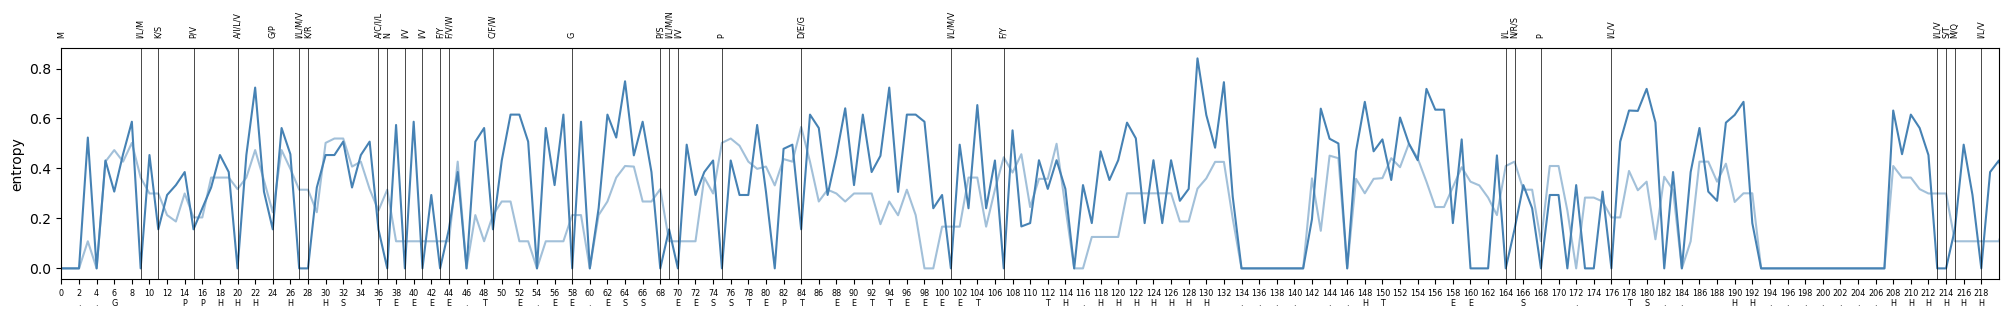

In [50]:
def get_entropy(msa, alphabet:dict=None, exclude_gaps:bool=False):

    alphabet_size = 20 if (alphabet is None) else len(np.unique(list(alphabet.values())))

    entropy = list()
    for col in msa.to_array(alphabet=alphabet).T:
        if (exclude_gaps and ('-' in col)) or (len(col[col != MSA.gap_symbol]) == 0):
            entropy.append(np.nan)
            continue 
        _, counts = np.unique(col[col != MSA.gap_symbol], return_counts=True)
        frequencies = counts / counts.sum()
        entropy.append(sum(-(frequencies * np.log(frequencies) / np.log(alphabet_size))))
    return np.array(entropy)

fig, ax = plt.subplots(figsize=(25, 3))
MAX_ENTROPY = 0.2
# x_min, x_max = 240, 270

x_min, x_max = 0, 220 
entropy = get_entropy(msa, alphabet=REDUCED_ALPHABET)
dssp_entropy = get_entropy(dssp_msa)

ax.plot(np.arange(len(entropy)), entropy, color='steelblue')
ax.plot(np.arange(len(dssp_entropy)), dssp_entropy, color='steelblue', alpha=0.5)

conserved_idxs = np.where((entropy < MAX_ENTROPY) & (~np.isnan(entropy)))[0] 
conserved_idxs = [idx for idx in conserved_idxs if (MSA.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

for idx, aas in zip(conserved_idxs, conserved_aas):
    if (idx > x_max) or (idx < x_min):
        continue
    ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
    ax.axvline(idx, color='black', lw=0.5)

dssp_consensus = dssp_msa.get_consensus()
x_ticks = np.arange(x_min, x_max, 2)
x_tick_labels = [f'{x}\n{dssp_consensus[x]}' for x in x_ticks]

ax.set_xticks(x_ticks, x_tick_labels, fontsize='xx-small')
ax.set_xlim(xmin=x_min, xmax=x_max)
ax.set_ylabel('entropy')
plt.show()

# Multiple Foldseek hits related to metal binding, which would be mediated by acidic residues (D or E). None of these appear conserved.


In [22]:
FOLDSEEK_SEARCH_FIELDS = ['query', 'target', 'evalue', 'gapopen', 'pident', 'fident', 'nident', 'qstart', 'qend', 'qlen', 'tstart', 'tend', 'tlen', 'alnlen', 'bits', 'cigar', 'qseq', 'tseq', 'qheader', 'theader', 'qaln', 'taln', 'mismatch', 'qcov', 'tcov','taxid', 'taxname', 'taxlineage', 'lddt', 'lddtfull', 'qtmscore', 'ttmscore', 'alntmscore', 'rmsd', 'prob']
foldseek_search_target_database_pattern = r'alphafold_swissprot|alphafold_uniprot|pdb|bfvd'

paths = {re.search(foldseek_search_target_database_pattern, path).group(0):path for path in glob.glob('../data/genes/foldseek/*') if re.search(foldseek_search_target_database_pattern, path)}
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_SEARCH_FIELDS).assign(target_database=target_database) for target_database, path in paths.items()])
foldseek_search_df = foldseek_search_df.drop_duplicates(['query', 'target'])
foldseek_search_df = foldseek_search_df[foldseek_search_df['query'].isin(genes_df.index)].copy()

for gene_id, df in foldseek_search_df.groupby('query'):
    print(f'Number of Foldseek hits for {gene_id}: {len(df)}')

Number of Foldseek hits for orfm.bz_0.1_169: 1071
Number of Foldseek hits for orfm.bz_1.1_143: 1295
Number of Foldseek hits for orfm.bz_10.1_27: 1216
Number of Foldseek hits for orfm.bz_2.1_38: 1046
Number of Foldseek hits for orfm.bz_3.1_56: 711
Number of Foldseek hits for orfm.bz_4.1_159: 1311
Number of Foldseek hits for orfm.bz_5.1_136: 1064
Number of Foldseek hits for orfm.bz_7.1_170: 2150
Number of Foldseek hits for orfm.bz_8.1_202: 1603
Number of Foldseek hits for orfm.bz_9.1_58: 445


In [23]:
filters = dict()
filters['target_too_short'] = foldseek_search_df.tlen < 100
filters['target_too_long'] = foldseek_search_df.tlen > 350
filters['low_query_coverage'] = foldseek_search_df.qcov < 0.5
filters['low_tm_score'] = foldseek_search_df.alntmscore < 0.6
filters['fragment'] = foldseek_search_df.theader.str.contains('fragment', case=False)

foldseek_search_df = apply_filters(filters,foldseek_search_df)

# An overwhelming number of hits are for orfm.bz_7.1_170. 
for gene_id, df in foldseek_search_df.groupby('query'):
    print(f'Number of Foldseek hits for {gene_id}: {len(df)}')

apply_filters: 569 entries removed by target_too_short.
apply_filters: 4171 entries removed by target_too_long.
apply_filters: 1191 entries removed by low_query_coverage.
apply_filters: 11527 entries removed by low_tm_score.
apply_filters: 300 entries removed by fragment.
Number of Foldseek hits for orfm.bz_1.1_143: 3
Number of Foldseek hits for orfm.bz_10.1_27: 9
Number of Foldseek hits for orfm.bz_2.1_38: 3
Number of Foldseek hits for orfm.bz_3.1_56: 4
Number of Foldseek hits for orfm.bz_4.1_159: 5
Number of Foldseek hits for orfm.bz_7.1_170: 195
Number of Foldseek hits for orfm.bz_8.1_202: 5


In [ ]:
foldseek_search_df.sort_values('qcov')[['theader', 'alntmscore', 'qcov', 'tcov', 'qstart', 'qend']].iloc[-30:]
print('Number of Foldseek hits passing filters:', len(foldseek_search_df))

foldseek_search_categories = dict()
foldseek_search_categories['carboxypeptidase regulatory-like domain'] = foldseek_search_df.theader.str.contains('carboxypeptidase', case=False)
foldseek_search_categories['fibronectin'] = foldseek_search_df.theader.str.contains('fibronectin', case=False) # Fibronectin is a large, sticky protein that acts as a glue, connects cells to the extracellular matrix
foldseek_search_categories['RimM'] = foldseek_search_df.theader.str.contains('RimM') # Ribosome maturation factor. 
foldseek_search_categories['Ig-like'] = foldseek_search_df.theader.str.contains('Thy-1|Ig|immunoglobulin|IMMUNOGLOBULIN', case=True) # Thy-1 membrane glycoprotein is a mammalian protein (involved in cell-cell communication).  bacteria possess immunoglobulin-like domains (Ig-like folds) that serve as evolutionary predecessors or structural homologs to eukaryotic Ig proteins.  
foldseek_search_categories['Fab'] = foldseek_search_df.theader.str.contains('Fab', case=True) # The "Fab" in immunology stands for fragment antigen-binding. It is a specific piece of an antibody. 
foldseek_search_categories['PilZ'] = foldseek_search_df.theader.str.contains('PilZ', case=True) # PilZ domains possess the conserved RxxxR and DxSxxG motifs involved in binding cyclic di-GMP, which are absent from Ig domains.
foldseek_search_categories['uncharacterized'] = foldseek_search_df.theader.str.contains('uncharacterized', case=True) 
foldseek_search_categories['metal-sensing transcriptional repressor'] = foldseek_search_df.theader.str.contains('Metal-sensing transcriptional repressor|Copper-sensing transcriptional repressor', case=False)
foldseek_search_categories['lipid binding'] = foldseek_search_df.theader.str.contains('RIM1alpha C2B domain') # This has no membrane domain. 
foldseek_search_categories['synaptotagmin'] = foldseek_search_df.theader.str.contains('Synaptotagmin', case=False) # Membrane-bound and calcium-binding. 


foldseek_search_df['category'] = np.select(*list(zip(*list(foldseek_search_categories.items())))[::-1], default='none')

print('\n'.join(foldseek_search_df[foldseek_search_df.category == 'RimM'].theader))
foldseek_search_df.category.value_counts()

# This hits to metal-sensing transcriptional repressors are around residues 10-100, which appears to be a completely disordered region. 
# The Ig-like domain hits are more valid, they align to the beta sheet section. 
# Hits to RimM are to the C-terminal domain (beta sheets), "binds directly to ribosomal protein S19 to physically attach it to the 16S ribosomal RNA." Seems unlikely to be relevant due to membrane association. 
false_positive_foldseek_search_categories = ['metal-sensing transcriptional repressor', 'RimM']

Number of Foldseek hits passing filters: 224
AF-Q0TPP3-F1-model_v6 Ribosome maturation factor RimM
AF-Q8XJP6-F1-model_v6 Ribosome maturation factor RimM
AF-Q0SSB0-F1-model_v6 Ribosome maturation factor RimM
AF-B2TJ30-F1-model_v6 Ribosome maturation factor RimM
AF-A5I4M4-F1-model_v6 Ribosome maturation factor RimM
AF-Q895M3-F1-model_v6 Ribosome maturation factor RimM
AF-A7GG34-F1-model_v6 Ribosome maturation factor RimM
AF-A7FW10-F1-model_v6 Ribosome maturation factor RimM
AF-A0A4Y9J3Z0-F1-model_v6 Ribosome maturation factor RimM


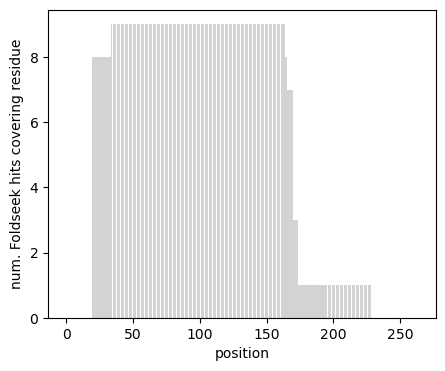

In [43]:
plot_foldseek_search_coverage(msa, foldseek_search_df=foldseek_search_df[foldseek_search_df.category == 'RimM'])

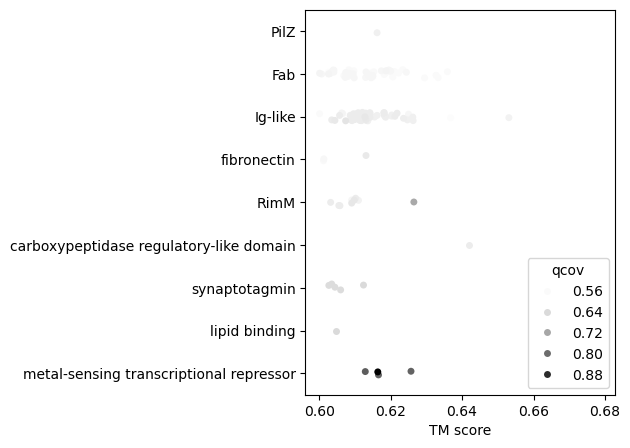

In [33]:
fig, ax = plt.subplots(figsize=(4, 5))

figure_df = foldseek_search_df[foldseek_search_df.category != 'none'].copy()
figure_df = figure_df.sort_values('qcov')
sns.stripplot(figure_df, x='alntmscore', y='category', hue='qcov', palette='Grays')
ax.set_ylabel('')
ax.set_xlabel('TM score')
plt.show()

In [28]:
# INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
# annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
# annot_df[annot_df.gene_id.isin(genes_df.index)]

In [29]:
# fig, ax = plt.subplots(figsize=(4, 4))

# figure_df = get_pairwise_alignments(genes_df.seq)
# for i in range(len(figure_df)):
#     figure_df.iloc[i, i] = 1
# figure_df = np.log(figure_df)

# sns.heatmap(figure_df, cbar=False, cmap='Blues', lw=0.7, linecolor='white')
# ax.set_ylabel('')
# ax.set_xlabel('')

# cluster_7_gene_ids.remove('orfm.bz_11.1_67')
# genes_df = pd.read_csv('../data/genes.csv', index_col=0)
# genes_df = genes_df.loc[cluster_7_gene_ids].copy()
# FASTAFile.from_df(genes_df).write('../data/genes/cluster_7.faa')